##### ### The University of Melbourne, School of Computing and Information Systems
# COMP30027 Machine Learning, 2026 Semester 1

## Assignment 1: Income Classification with Naïve Bayes


**Student ID(s):**     1536180


This iPython notebook is a template which you will use for your Assignment 1 submission.

**NOTE: YOU SHOULD ADD YOUR RESULTS, GRAPHS, AND FIGURES FROM YOUR OBSERVATIONS IN THIS FILE TO YOUR REPORT (the PDF file).** Results, figures, etc. which appear in this file but are NOT included in your report will not be marked.

**Adding proper comments to your code is MANDATORY. **

# Read me
## How to Run
1. Set `DATA_DIR` to your local data path
2. Run all cells in order from top to bottom
3. Python 3.13+ with sklearn, pandas, numpy, matplotlib required

## 1. Supervised model training


### import library

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Define feature list

In [124]:
# Continuous features: Numerical type, modeled with Gaussian distribution
CONTINUOUS_FEATURES = ['age', 'education-num', 'capital-gain', 
                        'capital-loss', 'hours-per-week']

# Categorical features: Categorical type, modeled with categorical distribution
CATEGORICAL_FEATURES = ['workclass', 'education', 'marital-status', 
                         'occupation', 'relationship', 'race', 
                         'sex', 'native-country']

# Feature set: Combined list of all features, facilitating the handling of missing values
ALL_FEATURES = CONTINUOUS_FEATURES + CATEGORICAL_FEATURES

# Target variable
TARGET = 'income'

### import data

In [125]:
# Define data directory(please change this to your own path if needed)
import os


DATA_DIR = 'COMP30027_2026_Assignment1_data/Assignment1_data/'

# import datasets with labels
train_df = pd.read_csv(DATA_DIR + 'adult_supervised_train.csv')

# import test dataset
test_df = pd.read_csv(DATA_DIR + 'adult_test.csv')

# import unlabelled dataset(Q3)
unlabelled_df = pd.read_csv(DATA_DIR + 'adult_unlabelled.csv')

# import unlabelled dataset with true labels(Q3 Option2)
unlabelled_with_labels_df = pd.read_csv(DATA_DIR + 'adult_unlabelled_with_labels.csv')

print("size of training set:", train_df.shape)
print("size of test set:", test_df.shape)
print("size of unlabelled set:", unlabelled_df.shape)

size of training set: (16280, 15)
size of test set: (16281, 15)
size of unlabelled set: (16281, 14)


### data preprocessing

In [126]:
# Preprocessing function to clean and prepare the data for modeling
def preprocess(df, is_labelled=True):
    # copy to avoid modifying the original data
    df = df.copy()
    
    # drop the fnlwgt column (sampling weight, not a prediction feature)
    if 'fnlwgt' in df.columns:
        df = df.drop(columns=['fnlwgt'])
    
    # drop rows with missing values (only check feature columns)
    df = df.dropna(subset=ALL_FEATURES)
    
    # convert income to 0/1 (only for labelled data)
    if is_labelled and TARGET in df.columns:
        df[TARGET] = (df[TARGET] == '>50K').astype(int)
    
    return df

# Preprocess the datasets
train_clean = preprocess(train_df, is_labelled=True)
test_clean  = preprocess(test_df,  is_labelled=True)

print("check the size of train set:", train_clean.shape)
print("check the size of test set:", test_clean.shape)
print("\ntraining set income distribution:")
print(train_clean[TARGET].value_counts())

check the size of train set: (15076, 14)
check the size of test set: (15087, 14)

training set income distribution:
income
0    11369
1     3707
Name: count, dtype: int64


### Train the Mixed Naive Bayes model

In [127]:
# devide features and target
X_train_cont = train_clean[CONTINUOUS_FEATURES]   # Continuous features
X_train_cat  = train_clean[CATEGORICAL_FEATURES]  # Categorical features
y_train      = train_clean[TARGET]                # Labels

Prior Probabilities P(c)
P(<=50K) = 0.7541 (75.4%)
P(>50K)  = 0.2459 (24.6%)


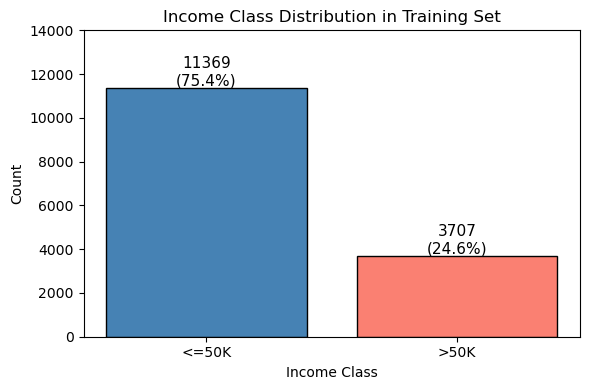

In [128]:
# Q1.1 Calculate prior probability P(c)
def calc_prior(y):
    # Count the quantity of each category
    n_total = len(y)
    classes = y.unique()
    
    prior = {}
    for c in classes:
        # The quantity of this category divided by the total quantity
        prior[c] = (y == c).sum() / n_total
    
    return prior

# Calculate prior probabilities
prior = calc_prior(y_train)

print("=" * 40)
print("Prior Probabilities P(c)")
print("=" * 40)
print(f"P(<=50K) = {prior[0]:.4f} ({prior[0]*100:.1f}%)")
print(f"P(>50K)  = {prior[1]:.4f} ({prior[1]*100:.1f}%)")

plt.figure(figsize=(6, 4))

# plot the bar chart of income class distribution
income_counts = train_clean[TARGET].value_counts().sort_index()
bars = plt.bar(['<=50K', '>50K'], income_counts.values, 
               color=['steelblue', 'salmon'], edgecolor='black')

# display count and percentage on top of each bar
for bar, count, pct in zip(bars, income_counts.values, [prior[0], prior[1]]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{count}\n({pct*100:.1f}%)', ha='center', fontsize=11)

plt.title('Income Class Distribution in Training Set')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.ylim(0, 14000)
plt.tight_layout()
plt.show()

In [129]:
# Q1.2 Train Mixed Naive Bayes Model
# Train GaussianNB on continuous features
gnb = GaussianNB()
gnb.fit(X_train_cont, y_train)
print("GaussianNB trained successfully")

# Encode categorical features: OrdinalEncoder converts text to numbers
# handle_unknown='use_encoded_value' handles unseen categories in test set
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat_encoded = encoder.fit_transform(X_train_cat)

# min_categories tells the model how many possible values each feature has
# this ensures Laplace smoothing is calculated correctly
min_cats = [len(encoder.categories_[i]) for i in range(len(CATEGORICAL_FEATURES))]

# alpha=1.0 is the Laplace smoothing parameter
cnb = CategoricalNB(alpha=1.0, min_categories=min_cats)
cnb.fit(X_train_cat_encoded, y_train)
print("CategoricalNB trained successfully")

GaussianNB trained successfully
CategoricalNB trained successfully


In [130]:
# gnb.theta_ is save mean
# gnb.var_ is save variance

print("=" * 60)
print("Continuous Features: Mean and Standard Deviation per Class")
print("=" * 60)

for i, feature in enumerate(CONTINUOUS_FEATURES):
    mean_0 = gnb.theta_[0][i]  # <=50K (mean)
    mean_1 = gnb.theta_[1][i]  # >50K (mean)
    std_0  = np.sqrt(gnb.var_[0][i])  # <=50K (standard deviation)
    std_1  = np.sqrt(gnb.var_[1][i])  # >50K (standard deviation)

    print(f"\n{feature}:")
    print(f"  <=50K: mean={mean_0:.2f}, std={std_0:.2f}")
    print(f"  >50K:  mean={mean_1:.2f}, std={std_1:.2f}")
    print(f"  difference:  {abs(mean_1 - mean_0):.2f}")

Continuous Features: Mean and Standard Deviation per Class

age:
  <=50K: mean=37.05, std=13.71
  >50K:  mean=43.94, std=10.30
  difference:  6.89

education-num:
  <=50K: mean=9.63, std=2.45
  >50K:  mean=11.59, std=2.36
  difference:  1.97

capital-gain:
  <=50K: mean=157.67, std=1017.86
  >50K:  mean=3607.15, std=13616.62
  difference:  3449.48

capital-loss:
  <=50K: mean=55.97, std=316.02
  >50K:  mean=202.36, std=603.99
  difference:  146.39

hours-per-week:
  <=50K: mean=39.43, std=11.91
  >50K:  mean=45.64, std=10.40
  difference:  6.21


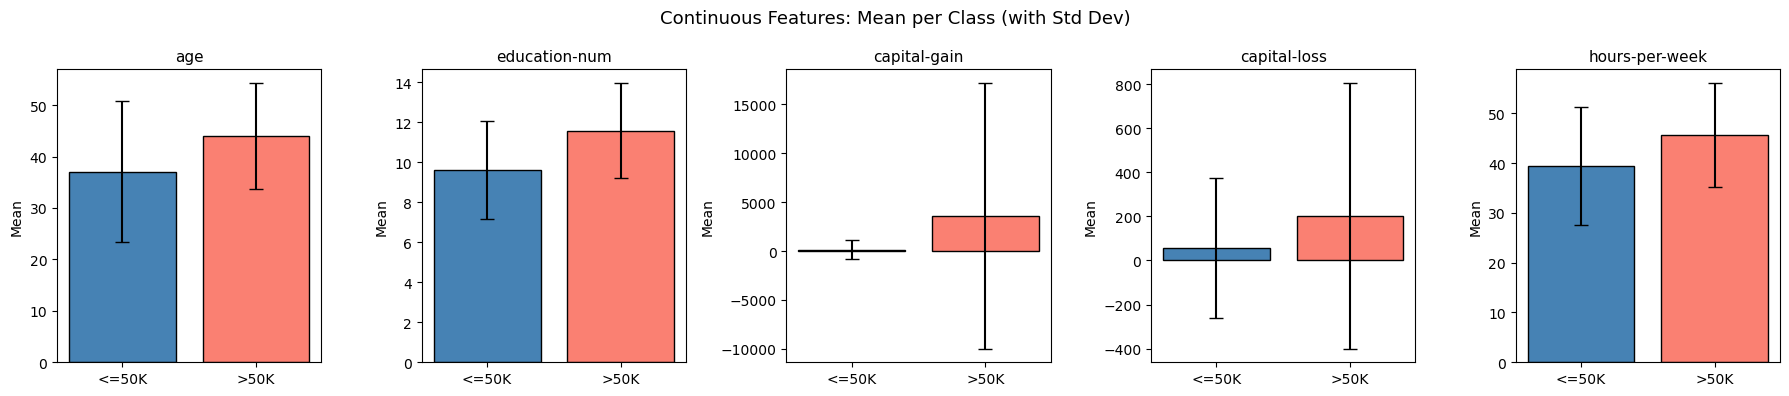

In [131]:
# Visualization of continuous feature mean comparison
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, (feature, ax) in enumerate(zip(CONTINUOUS_FEATURES, axes)):
    means = [gnb.theta_[0][i], gnb.theta_[1][i]]
    stds  = [np.sqrt(gnb.var_[0][i]), np.sqrt(gnb.var_[1][i])]
    
    # Draw a bar chart and add the standard deviation error bar
    bars = ax.bar(['<=50K', '>50K'], means, 
                  yerr=stds, capsize=5,
                  color=['steelblue', 'salmon'], edgecolor='black')
    
    ax.set_title(feature, fontsize=11)
    ax.set_ylabel('Mean')

plt.suptitle('Continuous Features: Mean per Class (with Std Dev)', fontsize=13)
plt.tight_layout()
plt.show()

In [132]:
# Q1.3 calculate R 
results = []

for i, feature in enumerate(CATEGORICAL_FEATURES):
    # Extract all the category values of this feature
    categories = encoder.categories_[i]
    
        # feature_log_prob_[i] is a 2×K array
    log_probs = cnb.feature_log_prob_[i]  # shape: (2, K)
    
    for j, category in enumerate(categories):
        prob_0 = np.exp(log_probs[0][j])  # P(value|<=50K)
        prob_1 = np.exp(log_probs[1][j])  # P(value|>50K)
        
        # R = P(value|>50K) / P(value|<=50K)
        R = prob_1 / prob_0 if prob_0 > 0 else float('inf')
        
        results.append({
            'feature': feature,
            'value': category,
            'P(<=50K)': round(prob_0, 4),
            'P(>50K)':  round(prob_1, 4),
            'R':        round(R, 4)
        })

results_df = pd.DataFrame(results)

# The top 5 with the most predicted values above 50K (largest R)
print("=" * 60)
print("Top 5 most predictive values for >50K (highest R)")
print("=" * 60)
print(results_df.nlargest(5, 'R')[['feature', 'value', 'P(<=50K)', 'P(>50K)', 'R']].to_string(index=False))

# The top 5 with the most predicted values below 50K (lowest R)
print("\n" + "=" * 60)
print("Top 5 most predictive values for <=50K (lowest R)")
print("=" * 60)
print(results_df.nsmallest(5, 'R')[['feature', 'value', 'P(<=50K)', 'P(>50K)', 'R']].to_string(index=False))

Top 5 most predictive values for >50K (highest R)
       feature             value  P(<=50K)  P(>50K)      R
     education       Prof-school    0.0069   0.0545 7.9587
     education         Doctorate    0.0045   0.0320 7.1354
marital-status Married-AF-spouse    0.0004   0.0019 4.2882
     education           Masters    0.0357   0.1268 3.5551
native-country            Taiwan    0.0008   0.0027 3.3832

Top 5 most predictive values for <=50K (lowest R)
     feature           value  P(<=50K)  P(>50K)      R
relationship       Own-child    0.1858   0.0097 0.0522
  occupation Priv-house-serv    0.0064   0.0005 0.0838
  occupation   Other-service    0.1389   0.0188 0.1354
relationship  Other-relative    0.0373   0.0054 0.1445
   education             9th    0.0196   0.0030 0.1508


## 2. Supervised model evaluation

## !!!!!

In [133]:
# Q2.1 Prediction function
def predict_mixed_nb(gnb, cnb, X_cont, X_cat_encoded):
    # Handle OOV: Replace -1 with 0
    X_cat_encoded = np.where(X_cat_encoded < 0, 0, X_cat_encoded)
    
    # joint log probability of continuous features
    log_joint_cont = gnb.predict_joint_log_proba(X_cont)
    
    # Categorical features: manually calculate log likelihood
    # Extract log P(x_j|c) directly from cnb.feature_log_prob_
    n_samples = X_cat_encoded.shape[0]
    n_classes = len(cnb.classes_)
    log_likelihood_cat = np.zeros((n_samples, n_classes))
    
    for i in range(len(CATEGORICAL_FEATURES)):
        feature_vals = X_cat_encoded[:, i].astype(int)
        for c in range(n_classes):
            log_likelihood_cat[:, c] += cnb.feature_log_prob_[i][c][feature_vals]
    
    # Merge: gnb_joint already contains the prior, and add the likelihood of the category
    log_joint_total = log_joint_cont + log_likelihood_cat
    
    # Prediction
    y_pred = np.argmax(log_joint_total, axis=1)
    
    # Confidence level R
    log_R = log_joint_total[:, 1] - log_joint_total[:, 0]
    R_values = np.exp(log_R)
    
    return y_pred, R_values, log_joint_total

# Preprocess test set
X_test_cont        = test_clean[CONTINUOUS_FEATURES]
X_test_cat         = test_clean[CATEGORICAL_FEATURES]
y_test             = test_clean[TARGET]
X_test_cat_encoded = encoder.transform(X_test_cat)

# Prediction
y_pred, R_values, log_joint_total = predict_mixed_nb(gnb, cnb, X_test_cont, X_test_cat_encoded)

print("Prediction completed!")
print("Distribution of predicted results:")
print(pd.Series(y_pred).value_counts())

Prediction completed!
Distribution of predicted results:
0    12341
1     2746
Name: count, dtype: int64


C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


Overall Accuracy
0.8307

Classification Report
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89     11303
        >50K       0.72      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087



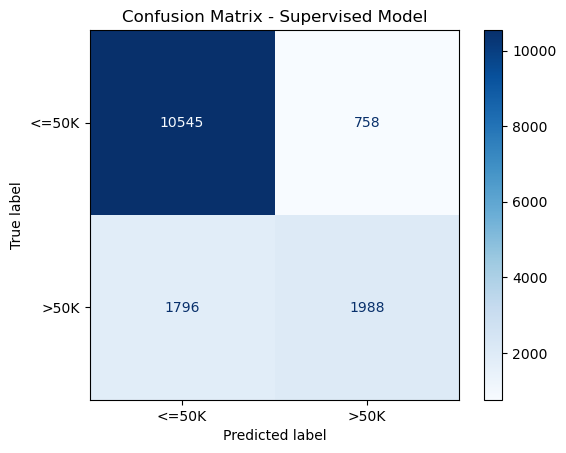

In [134]:
# Q2.1 model evaluation: Accuracy rate, confusion matrix , precision/recall/F1

print("=" * 50)
print("Overall Accuracy")
print("=" * 50)
print(f"{accuracy_score(y_test, y_pred):.4f}")

print("\n" + "=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Supervised Model')
plt.show()

In [135]:
# Q2.2 OOV analyse - Category values that were not seen in the training set appeared in the test set

# Re-transform the test set while retaining the -1
X_test_cat_raw = encoder.transform(X_test_cat)

# Find the rows containing -1 (i.e., the rows containing OOV values)
oov_mask = (X_test_cat_raw == -1).any(axis=1)

print("=" * 50)
print("OOV Analysis")
print("=" * 50)
print(f"The total number of rows in the test set: {len(X_test_cat_raw)}")
print(f"Rows containing OOV values: {oov_mask.sum()}")
print(f"OOV proportion: {oov_mask.sum() / len(X_test_cat_raw) * 100:.2f}%")

# Find which features have OOV values
print("\nOOV counts for each feature:")
for i, feature in enumerate(CATEGORICAL_FEATURES):
    n_oov = (X_test_cat_raw[:, i] == -1).sum()
    if n_oov > 0:
        print(f"  {feature}: {n_oov} OOV value")

print("\nthe ways to handle OOV values:")
print("OOV values are encoded as -1, replaced with 0 before prediction")
print("i.e., the first known category value for that feature is used, to avoid CategoricalNB errors")

OOV Analysis
The total number of rows in the test set: 15087
Rows containing OOV values: 1
OOV proportion: 0.01%

OOV counts for each feature:
  native-country: 1 OOV value

the ways to handle OOV values:
OOV values are encoded as -1, replaced with 0 before prediction
i.e., the first known category value for that feature is used, to avoid CategoricalNB errors


In [136]:
# Q2.3 Confidence Analysis
# R = P(>50K|x) / P(<=50K|x)
# The larger R is: the more certain it is >50K
# The smaller R is: the more certain it is <=50K
# R≈1: model uncertainty

# Integrate the results into a table
analysis_df = test_clean[ALL_FEATURES].copy()
analysis_df['true_label'] = y_test.values
analysis_df['pred_label'] = y_pred
analysis_df['R'] = R_values

# inf Replace it with a larger number for easier sorting
analysis_df['R'] = analysis_df['R'].replace([np.inf], 1e10)

# High confidence predictions for >50K
print("Top 3: High confidence predictions for >50K")
top_high = analysis_df[analysis_df['pred_label'] == 1].nlargest(3, 'R')
print(top_high[['age', 'education', 'occupation', 'marital-status', 
                'capital-gain', 'true_label', 'R']])

# High confidence predictions for <=50K
print("\nTop 3: High confidence predictions for <=50K")
top_low = analysis_df[analysis_df['pred_label'] == 0].nsmallest(3, 'R')
print(top_low[['age', 'education', 'occupation', 'marital-status', 
               'capital-gain', 'true_label', 'R']])

# Near the decision boundary R≈1
print("\nTop 3: Near the decision boundary (R≈1)")
analysis_df['R_dist'] = abs(analysis_df['R'] - 1)
boundary = analysis_df.nsmallest(3, 'R_dist')
print(boundary[['age', 'education', 'occupation', 'marital-status',
                'capital-gain', 'pred_label', 'true_label', 'R']])

Top 3: High confidence predictions for >50K
       age    education       occupation marital-status  capital-gain  \
9830    51  Prof-school   Prof-specialty       Divorced         27828   
3963    37      Masters  Exec-managerial      Separated         27828   
16090   53  Prof-school   Prof-specialty  Never-married         27828   

       true_label              R  
9830            1  1.212215e+160  
3963            1  1.292139e+159  
16090           1  9.318333e+158  

Top 3: High confidence predictions for <=50K
       age education     occupation marital-status  capital-gain  true_label  \
13228   18      10th  Other-service  Never-married             0           0   
3216    17      10th  Other-service  Never-married             0           0   
10584   17      11th  Other-service  Never-married             0           0   

                  R  
13228  9.242193e-10  
3216   1.074523e-09  
10584  1.107104e-09  

Top 3: Near the decision boundary (R≈1)
      age  education       

## 3. Extending the model with semi-supervised training

In [137]:
# Q3 Option 1: Label Propagation

# Step 1

# separated a validation set from training set to select the threshold

# Split 20% from the training set as the validation set
train_sub, val_sub = train_test_split(train_clean, test_size=0.2, 
                                      random_state=42, stratify=train_clean[TARGET])

print(f"Training subset size: {train_sub.shape}")
print(f"Validation set size: {val_sub.shape}")
print(f"Validation set income distribution:")
print(val_sub[TARGET].value_counts())

Training subset size: (12060, 14)
Validation set size: (3016, 14)
Validation set income distribution:
income
0    2274
1     742
Name: count, dtype: int64


In [138]:
# Q3 Step 2: Pseudo-label unlabeled data
# Preprocess the unlabeled data
unlabelled_clean = preprocess(unlabelled_df, is_labelled=False)

X_unlab_cont        = unlabelled_clean[CONTINUOUS_FEATURES]
X_unlab_cat         = unlabelled_clean[CATEGORICAL_FEATURES]
X_unlab_cat_encoded = encoder.transform(X_unlab_cat)

# Predict pseudo-labels and confidence levels using the Q1 model
pseudo_pred, pseudo_R, _ = predict_mixed_nb(gnb, cnb, X_unlab_cont, X_unlab_cat_encoded)

print(f"The total amount of unlabeled data: {len(pseudo_pred)}")
print(f"Pseudo-label distribution:")
print(pd.Series(pseudo_pred).value_counts())

The total amount of unlabeled data: 15059
Pseudo-label distribution:
0    12402
1     2657
Name: count, dtype: int64


C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


In [139]:
# Q3 Step 3a: Basic Version - Retrained with all pseudo-labels

# Add pseudo-labels to unlabeled data
pseudo_df = unlabelled_clean.copy()
pseudo_df[TARGET] = pseudo_pred

# check NaN values in pseudo_df
print(f"Pseudo-label NaN count: {pseudo_df[TARGET].isna().sum()}")

# Merge the training set + all pseudo-labeled data
combined_all = pd.concat([train_clean, pseudo_df], ignore_index=True)
print(f"Original training set: {len(train_clean)}")
print(f"Pseudo-labeled data: {len(pseudo_df)}")
print(f"After merging: {len(combined_all)}")

# Retraining
X_comb_cont = combined_all[CONTINUOUS_FEATURES]
X_comb_cat  = combined_all[CATEGORICAL_FEATURES]
y_comb      = combined_all[TARGET]

encoder_all = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_comb_cat_enc = encoder_all.fit_transform(X_comb_cat)
min_cats_all = [len(encoder_all.categories_[i]) for i in range(len(CATEGORICAL_FEATURES))]

gnb_all = GaussianNB()
gnb_all.fit(X_comb_cont, y_comb)

cnb_all = CategoricalNB(alpha=1.0, min_categories=min_cats_all)
cnb_all.fit(X_comb_cat_enc, y_comb)

# Evaluate on the validation set
X_val_enc_all = encoder_all.transform(X_val_cat)
val_pred_all, _, _ = predict_mixed_nb(gnb_all, cnb_all, X_val_cont, X_val_enc_all)
acc_all = accuracy_score(y_val, val_pred_all)
print(f"\nBasic Version Val Accuracy: {acc_all:.4f}")

Pseudo-label NaN count: 0
Original training set: 15076
Pseudo-labeled data: 15059
After merging: 30135



Basic Version Val Accuracy: 0.8064


C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


In [140]:
# Q3 Step 3b:Improved version - Try different thresholds

print("Threshold | Retained count | Val Accuracy")
print("-" * 45)

best_acc = 0
best_t = 5

for t in [2, 5, 10, 20]:
    # Filter high-confidence pseudo-labels according to the threshold
    mask = (pseudo_R > t) | (pseudo_R < 1/t)
    
    # merging data
    pseudo_conf = unlabelled_clean[mask].copy()
    pseudo_conf[TARGET] = pseudo_pred[mask]
    combined = pd.concat([train_clean, pseudo_conf], ignore_index=True)
    
    # Train new model
    enc_t = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat_t = enc_t.fit_transform(combined[CATEGORICAL_FEATURES])
    min_cats_t = [len(enc_t.categories_[i]) for i in range(len(CATEGORICAL_FEATURES))]
    
    gnb_t = GaussianNB()
    gnb_t.fit(combined[CONTINUOUS_FEATURES], combined[TARGET])
    cnb_t = CategoricalNB(alpha=1.0, min_categories=min_cats_t)
    cnb_t.fit(X_cat_t, combined[TARGET])
    
    # Validate on the validation set
    val_enc_t = enc_t.transform(X_val_cat)
    pred_t, _, _ = predict_mixed_nb(gnb_t, cnb_t, X_val_cont, val_enc_t)
    acc = accuracy_score(y_val, pred_t)
    
    # Record the best threshold and model
    if acc > best_acc:
        best_acc = acc
        best_t = t
        gnb2, cnb2, encoder2 = gnb_t, cnb_t, enc_t
    
    print(f"R > {t:<6}  {mask.sum():>6}     {acc:.4f}")

print(f"\nAll pseudo-labels: {acc_all:.4f}")
print(f"Best threshold: R > {best_t}, Accuracy: {best_acc:.4f}")

Threshold | Retained count | Val Accuracy
---------------------------------------------


C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


R > 2        14355     0.8060


C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)
C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


R > 5        13325     0.8060
R > 10       12494     0.8067
R > 20       11537     0.8103

All pseudo-labels: 0.8064
Best threshold: R > 20, Accuracy: 0.8103


C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


In [141]:
# Q3 Summary and comparison
# First take the accuracy of the Q1 model on the validation set as the benchmark
val_pred_q1, _, _ = predict_mixed_nb(gnb, cnb, X_val_cont, 
                                      encoder.transform(X_val_cat))
acc_q1 = accuracy_score(y_val, val_pred_q1)

print("=" * 50)
print("Q3 Summary: Validation Set Results")
print("=" * 50)
print(f"Q1 supervised model:        {acc_q1:.4f}")
print(f"All pseudo-labels:          {acc_all:.4f}")
print(f"Best threshold (R > {best_t}):   {best_acc:.4f}")
print(f"\nSelected model: R > {best_t}")

C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


Q3 Summary: Validation Set Results
Q1 supervised model:        0.8302
All pseudo-labels:          0.8064
Best threshold (R > 20):   0.8103

Selected model: R > 20


## 4. Supervised model evaluation

In [142]:
# Q4 
# Compare the Q1 and Q3 models on the test set

# Q1 The performance of the model on the test set
y_pred_q1, R_q1, _ = predict_mixed_nb(gnb, cnb, X_test_cont, X_test_cat_encoded)
acc_q1_test = accuracy_score(y_test, y_pred_q1)

# Q3 The performance of the model (best: R > 20) on the test set
X_test_cat_enc2 = encoder2.transform(X_test_cat)
y_pred_q3, R_q3, _ = predict_mixed_nb(gnb2, cnb2, X_test_cont, X_test_cat_enc2)
acc_q3_test = accuracy_score(y_test, y_pred_q3)

# compare the results
print("=" * 50)
print("Q4: Test Set Comparison")
print("=" * 50)
print(f"\nQ1 supervised model:")
print(classification_report(y_test, y_pred_q1, target_names=['<=50K', '>50K']))

print(f"Q3 semi-supervised model (R > {best_t}):")
print(classification_report(y_test, y_pred_q3, target_names=['<=50K', '>50K']))

print(f"Q1 Accuracy: {acc_q1_test:.4f}")
print(f"Q3 Accuracy: {acc_q3_test:.4f}")
print(f"Difference:  {acc_q3_test - acc_q1_test:.4f}")

Q4: Test Set Comparison

Q1 supervised model:
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89     11303
        >50K       0.72      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087

Q3 semi-supervised model (R > 20):
              precision    recall  f1-score   support

       <=50K       0.84      0.93      0.88     11303
        >50K       0.69      0.45      0.55      3784

    accuracy                           0.81     15087
   macro avg       0.76      0.69      0.72     15087
weighted avg       0.80      0.81      0.80     15087

Q1 Accuracy: 0.8307
Q3 Accuracy: 0.8128
Difference:  -0.0180


C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)
C:\Users\liaml\AppData\Local\Temp\ipykernel_4216\1135866992.py:28: RuntimeWarning: overflow encountered in exp
  R_values = np.exp(log_R)


In [143]:
# Q4.2a Analysis of model parameter changes

# The mean change of continuous features
print("=" * 60)
print("Continuous Features: Mean Comparison (Q1 vs Q3)")
print("=" * 60)
print(f"{'Feature':<18} {'Q1 <=50K':>10} {'Q3 <=50K':>10} {'Q1 >50K':>10} {'Q3 >50K':>10}")
print("-" * 60)
for i, f in enumerate(CONTINUOUS_FEATURES):
    print(f"{f:<18} {gnb.theta_[0][i]:>10.2f} {gnb2.theta_[0][i]:>10.2f} "
          f"{gnb.theta_[1][i]:>10.2f} {gnb2.theta_[1][i]:>10.2f}")

# Changes in confidence distribution
print("\n" + "=" * 60)
print("Confidence Distribution (R values)")
print("=" * 60)
print(f"{'':>15} {'Q1 Model':>12} {'Q3 Model':>12}")
print(f"{'Mean R':<15} {np.nanmean(R_q1[R_q1 < 1e10]):>12.4f} {np.nanmean(R_q3[R_q3 < 1e10]):>12.4f}")
print(f"{'Median R':<15} {np.nanmedian(R_q1):>12.4f} {np.nanmedian(R_q3):>12.4f}")
print(f"{'R > 1 count':<15} {(R_q1 > 1).sum():>12} {(R_q3 > 1).sum():>12}")
print(f"{'R < 1 count':<15} {(R_q1 < 1).sum():>12} {(R_q3 < 1).sum():>12}")

Continuous Features: Mean Comparison (Q1 vs Q3)
Feature              Q1 <=50K   Q3 <=50K    Q1 >50K    Q3 >50K
------------------------------------------------------------
age                     37.05      36.42      43.94      44.09
education-num            9.63       9.52      11.59      11.69
capital-gain           157.67     100.91    3607.15    5754.23
capital-loss            55.97      31.65     202.36     354.59
hours-per-week          39.43      39.00      45.64      45.76

Confidence Distribution (R values)
                    Q1 Model     Q3 Model
Mean R          22729706.2957 18901443.2871
Median R              0.0037       0.0013
R > 1 count             2746         2477
R < 1 count            12341        12610


In [144]:
# Q4.2b Variance variation
print("=" * 60)
print("Continuous Features: Std Dev Comparison (Q1 vs Q3)")
print("=" * 60)
print(f"{'Feature':<18} {'Q1 <=50K':>10} {'Q3 <=50K':>10} {'Q1 >50K':>10} {'Q3 >50K':>10}")
print("-" * 60)
for i, f in enumerate(CONTINUOUS_FEATURES):
    print(f"{f:<18} {np.sqrt(gnb.var_[0][i]):>10.2f} {np.sqrt(gnb2.var_[0][i]):>10.2f} "
          f"{np.sqrt(gnb.var_[1][i]):>10.2f} {np.sqrt(gnb2.var_[1][i]):>10.2f}")

# Q4.2c Whether the most predictive category features have changed
print("\n" + "=" * 60)
print("Top 5 Predictive Values: Q1 vs Q3")
print("=" * 60)

# Q3 The R value of the model
results_q3 = []
for i, feature in enumerate(CATEGORICAL_FEATURES):
    categories = encoder2.categories_[i]
    log_probs = cnb2.feature_log_prob_[i]
    
    for j, category in enumerate(categories):
        prob_0 = np.exp(log_probs[0][j])
        prob_1 = np.exp(log_probs[1][j])
        R = prob_1 / prob_0 if prob_0 > 0 else float('inf')
        results_q3.append({'feature': feature, 'value': category, 'R': round(R, 4)})

results_q3_df = pd.DataFrame(results_q3)

print("\nQ1 Top 5 for >50K:")
print(results_df.nlargest(5, 'R')[['feature', 'value', 'R']].to_string(index=False))

print("\nQ3 Top 5 for >50K:")
print(results_q3_df.nlargest(5, 'R')[['feature', 'value', 'R']].to_string(index=False))

print("\nQ1 Top 5 for <=50K:")
print(results_df.nsmallest(5, 'R')[['feature', 'value', 'R']].to_string(index=False))

print("\nQ3 Top 5 for <=50K:")
print(results_q3_df.nsmallest(5, 'R')[['feature', 'value', 'R']].to_string(index=False))

Continuous Features: Std Dev Comparison (Q1 vs Q3)
Feature              Q1 <=50K   Q3 <=50K    Q1 >50K    Q3 >50K
------------------------------------------------------------
age                     13.71      13.67      10.30      10.56
education-num            2.45       2.41       2.36       2.43
capital-gain          1017.86     773.89   13616.62   17183.77
capital-loss           316.02     237.76     603.99     762.77
hours-per-week          11.91      11.92      10.40      10.66

Top 5 Predictive Values: Q1 vs Q3

Q1 Top 5 for >50K:
       feature             value      R
     education       Prof-school 7.9587
     education         Doctorate 7.1354
marital-status Married-AF-spouse 4.2882
     education           Masters 3.5551
native-country            Taiwan 3.3832

Q3 Top 5 for >50K:
       feature        value       R
     education    Doctorate 13.3793
     education  Prof-school 13.3032
     workclass Self-emp-inc  4.7989
native-country       Taiwan  4.3176
     education 